/tmp/ipython-input-3329331277.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_6h = df[value_col].resample("6H").mean()
/tmp/ipython-input-3329331277.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_12h = df[value_col].resample("12H").mean()


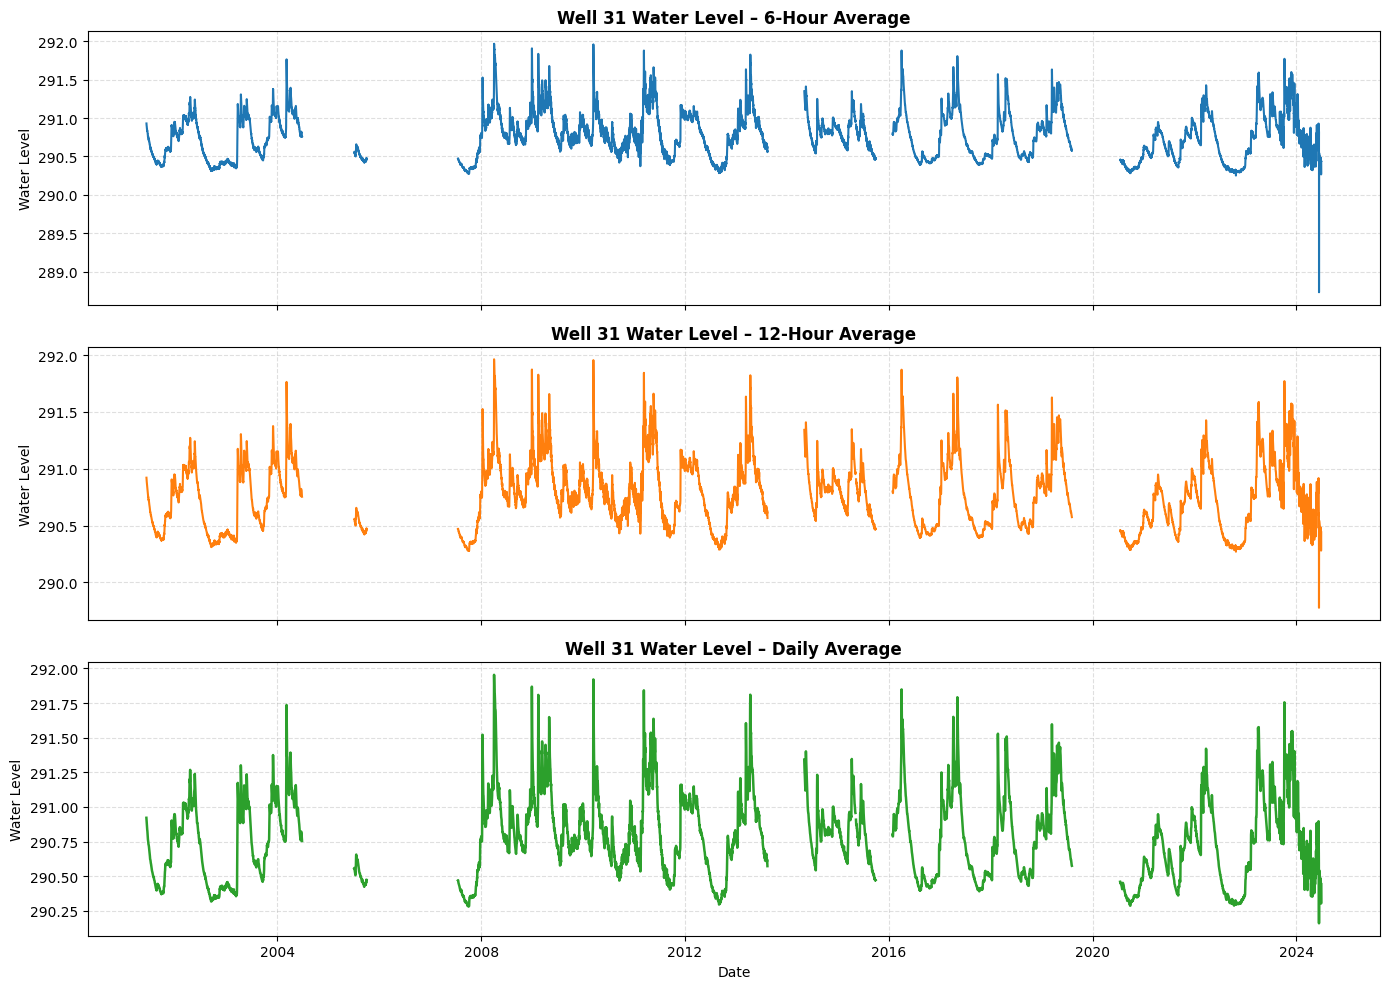

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# Load and prepare data
# -----------------------------
df = pd.read_csv("W0000031-1.csv")

# Parse datetime
df["READING_DTTM"] = pd.to_datetime(df["READING_DTTM"])
df = df.set_index("READING_DTTM").sort_index()

# Replace with your actual column name if different
value_col = "Water_Level_Elevation_meter_above_sea_level"

# -----------------------------
# Resample to different timescales
# -----------------------------
df_6h = df[value_col].resample("6H").mean()
df_12h = df[value_col].resample("12H").mean()
df_daily = df[value_col].resample("D").mean()

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(14, 10), sharex=True
)

colors = {
    "6h": "#1f77b4",
    "12h": "#ff7f0e",
    "daily": "#2ca02c"
}

axes[0].plot(df_6h.index, df_6h, color=colors["6h"], linewidth=1.5)
axes[0].set_title("Well 31 Water Level – 6-Hour Average", fontsize=12, weight="bold")
axes[0].set_ylabel("Water Level")

axes[1].plot(df_12h.index, df_12h, color=colors["12h"], linewidth=1.5)
axes[1].set_title("Well 31 Water Level – 12-Hour Average", fontsize=12, weight="bold")
axes[1].set_ylabel("Water Level")

axes[2].plot(df_daily.index, df_daily, color=colors["daily"], linewidth=1.8)
axes[2].set_title("Well 31 Water Level – Daily Average", fontsize=12, weight="bold")
axes[2].set_ylabel("Water Level")
axes[2].set_xlabel("Date")

# -----------------------------
# Axis formatting
# -----------------------------
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.tick_params(axis="both", labelsize=10)

axes[2].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(
    axes[2].xaxis.get_major_locator()
))

plt.tight_layout()
plt.savefig("well_31_water_level.png", dpi=300)
plt.show()
